In [3]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error

from sklearn.preprocessing import LabelEncoder

In [4]:
df = pd.read_csv("data/train.csv")

df.head()

,Id,MSSubClass,MSZoning,LotFrontage,LotArea,Street,Alley,LotShape,LandContour,Utilities,...,PoolArea,PoolQC,Fence,MiscFeature,MiscVal,MoSold,YrSold,SaleType,SaleCondition,SalePrice
0,1,60,RL,65.0,8450,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2008,WD,Normal,208500
1,2,20,RL,80.0,9600,Pave,NaN,Reg,Lvl,AllPub,...,0,NaN,NaN,NaN,0,5,2007,WD,Normal,181500
2,3,60,RL,68.0,11250,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,9,2008,WD,Normal,223500
3,4,70,RL,60.0,9550,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,2,2006,WD,Abnorml,140000
4,5,60,RL,84.0,14260,Pave,NaN,IR1,Lvl,AllPub,...,0,NaN,NaN,NaN,0,12,2008,WD,Normal,250000


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1460 entries, 0 to 1459
Data columns (total 81 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   Id             1460 non-null   int64  
 1   MSSubClass     1460 non-null   int64  
 2   MSZoning       1460 non-null   object 
 3   LotFrontage    1201 non-null   float64
 4   LotArea        1460 non-null   int64  
 5   Street         1460 non-null   object 
 6   Alley          91 non-null     object 
 7   LotShape       1460 non-null   object 
 8   LandContour    1460 non-null   object 
 9   Utilities      1460 non-null   object 
 10  LotConfig      1460 non-null   object 
 11  LandSlope      1460 non-null   object 
 12  Neighborhood   1460 non-null   object 
 13  Condition1     1460 non-null   object 
 14  Condition2     1460 non-null   object 
 15  BldgType       1460 non-null   object 
 16  HouseStyle     1460 non-null   object 
 17  OverallQual    1460 non-null   int64  
 18  OverallC

In [6]:
df.isnull().sum().sort_values(ascending=False)

PoolQC           1453
MiscFeature      1406
Alley            1369
Fence            1179
MasVnrType        872
                 ... 
MoSold              0
YrSold              0
SaleType            0
SaleCondition       0
SalePrice           0
Length: 81, dtype: int64

In [7]:
for col in df.columns:
    
    if df[col].dtype == "object":
        df[col] = df[col].fillna(df[col].mode()[0])
        
    else:
        df[col] = df[col].fillna(df[col].mean())

In [8]:
label_encoder = LabelEncoder()

for col in df.columns:
    
    if df[col].dtype == "object":
        df[col] = label_encoder.fit_transform(df[col])

In [9]:
X = df.drop("SalePrice", axis=1)

y = df["SalePrice"]

In [10]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [11]:
model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

model.fit(X_train, y_train)

,n_estimators,100
,criterion,'squared_error'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,1.0
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [12]:
predictions = model.predict(X_test)

predictions[:5]

array([141106.  , 326428.31, 118016.  , 163463.9 , 322579.61])

In [13]:
rmse = np.sqrt(mean_squared_error(y_test, predictions))

print("RMSE:", rmse)

RMSE: 28745.449131331778


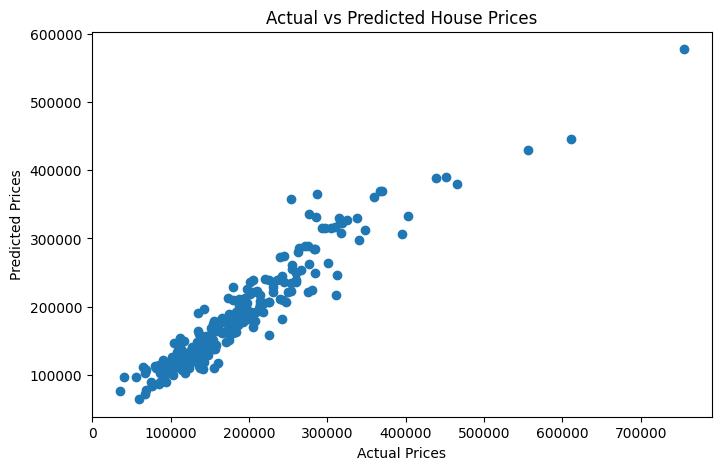

In [14]:
plt.figure(figsize=(8,5))

plt.scatter(y_test, predictions)

plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")

plt.title("Actual vs Predicted House Prices")

plt.savefig("images/actual_vs_predicted.png")

plt.show()

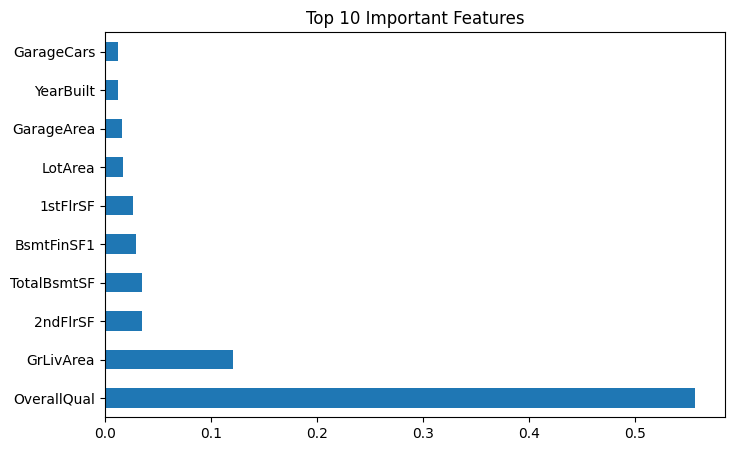

In [15]:
importance = pd.Series(
    model.feature_importances_,
    index=X.columns
)

top_features = importance.sort_values(ascending=False).head(10)

plt.figure(figsize=(8,5))

top_features.plot(kind="barh")

plt.title("Top 10 Important Features")

plt.savefig("images/feature_importance.png")

plt.show()

## Business Insights

1. Overall house quality significantly impacts house prices.

2. Living area and neighborhood-related features strongly influence predictions.

3. Random Forest Regressor provided effective house price predictions.

4. Feature importance analysis identified the most influential housing attributes.

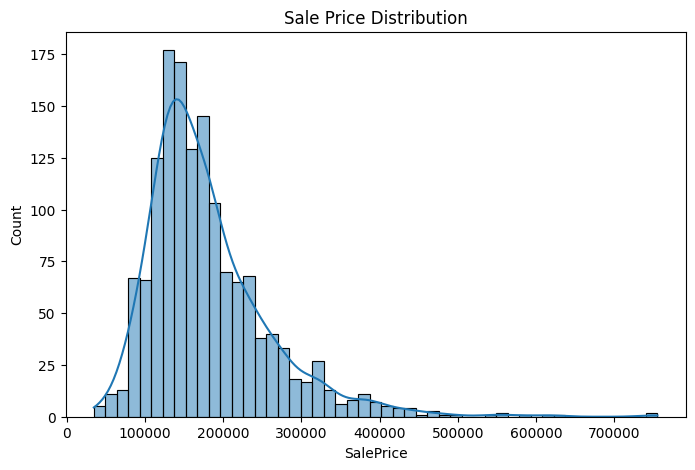

In [16]:
plt.figure(figsize=(8,5))

sns.histplot(df["SalePrice"], kde=True)

plt.title("Sale Price Distribution")

plt.savefig("images/saleprice_distribution.png")

plt.show()

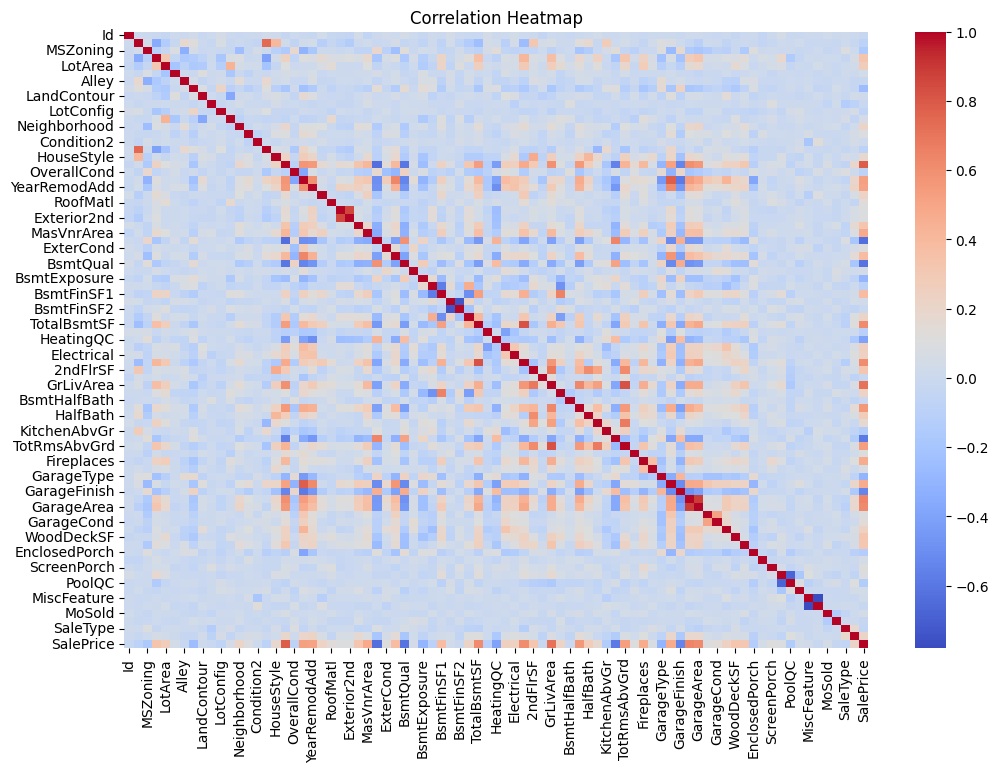

In [17]:
plt.figure(figsize=(12,8))

correlation = df.corr()

sns.heatmap(
    correlation,
    cmap="coolwarm"
)

plt.title("Correlation Heatmap")

plt.savefig("images/correlation_heatmap.png")

plt.show()

In [18]:
top_corr = correlation["SalePrice"].sort_values(ascending=False)

print(top_corr.head(15))

SalePrice       1.000000
OverallQual     0.790982
GrLivArea       0.708624
GarageCars      0.640409
GarageArea      0.623431
TotalBsmtSF     0.613581
1stFlrSF        0.605852
FullBath        0.560664
TotRmsAbvGrd    0.533723
YearBuilt       0.522897
YearRemodAdd    0.507101
MasVnrArea      0.475241
GarageYrBlt     0.470177
Fireplaces      0.466929
BsmtFinSF1      0.386420
Name: SalePrice, dtype: float64


In [19]:
from sklearn.linear_model import LinearRegression

lr_model = LinearRegression()

lr_model.fit(X_train, y_train)

lr_predictions = lr_model.predict(X_test)

lr_rmse = np.sqrt(mean_squared_error(y_test, lr_predictions))

print("Linear Regression RMSE:", lr_rmse)

Linear Regression RMSE: 35327.84964466267


In [20]:
rf_rmse = np.sqrt(mean_squared_error(y_test, predictions))

print("Random Forest RMSE:", rf_rmse)

Random Forest RMSE: 28745.449131331778


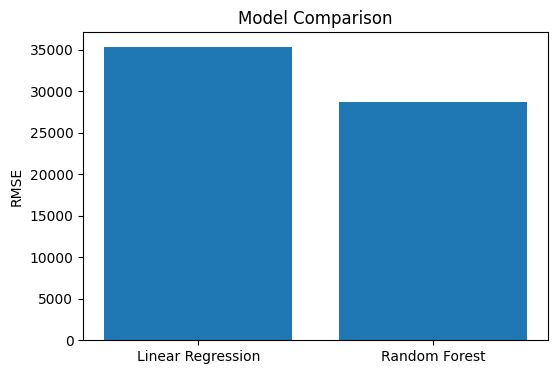

In [21]:
models = ["Linear Regression", "Random Forest"]

scores = [lr_rmse, rf_rmse]

plt.figure(figsize=(6,4))

plt.bar(models, scores)

plt.ylabel("RMSE")

plt.title("Model Comparison")

plt.savefig("images/model_comparison.png")

plt.show()

In [22]:
results = pd.DataFrame({
    "Actual Price": y_test,
    "Predicted Price": predictions
})

results.head()

,Actual Price,Predicted Price
892,154500,141106.00
1105,325000,326428.31
413,115000,118016.00
522,159000,163463.90
1036,315500,322579.61


In [23]:
results.to_csv("predictions.csv", index=False)